In [1]:
!pip install merlinquantum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.8/432.8 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from merlin import MeasurementStrategy, QuantumLayer
from merlin.builder import CircuitBuilder

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# 1) Data
# ============================================================

iris = load_iris()
X = iris.data.astype("float32")
y = iris.target.astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.24, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

# ============================================================
# 2) Reservoir (CORRECT VERSION)
# ============================================================

n_modes = 4
n_photons = 2
depth = 5

builder = CircuitBuilder(n_modes=n_modes)

# Encode ONCE
builder.add_angle_encoding(
    modes=list(range(n_modes)),
    name="input",
    scale=1.0
)

# Then apply multiple fixed nonlinear layers
for d in range(depth):
    builder.add_entangling_layer(trainable=False, name=f"U_{d}")
    builder.add_rotations(trainable=False, name=f"theta_{d}")
    builder.add_superpositions(depth=1, trainable=False, name=f"bs_{d}")

quantum_reservoir = QuantumLayer(
    input_size=4,   # Now matches exactly
    builder=builder,
    n_photons=n_photons,
    measurement_strategy=MeasurementStrategy.AMPLITUDES
)

# Freeze reservoir
for p in quantum_reservoir.parameters():
    p.requires_grad_(False)

print("Reservoir output_size:", quantum_reservoir.output_size)

# ============================================================
# 3) Readout
# ============================================================

class MerlinQRC(nn.Module):
    def __init__(self, reservoir, num_classes):
        super().__init__()
        self.reservoir = reservoir
        feat_dim = reservoir.output_size * 2  # real + imag
        self.readout = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        q = self.reservoir(x)
        q_feat = torch.cat([torch.real(q), torch.imag(q)], dim=1).float()
        return self.readout(q_feat)

model = MerlinQRC(quantum_reservoir, 3)

# ============================================================
# 4) Train
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 2000

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        train_acc = (logits.argmax(1) == y_train).float().mean().item()
        print(f"Epoch {epoch+1:3d} | loss={loss.item():.4f} | train_acc={train_acc:.3f}")

# ============================================================
# 5) Evaluate
# ============================================================

model.eval()
with torch.no_grad():
    train_acc = (model(X_train).argmax(1) == y_train).float().mean().item()
    test_acc  = (model(X_test).argmax(1) == y_test).float().mean().item()

print("\n==============================")
print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)
print("==============================")

Reservoir output_size: 6
Epoch  50 | loss=0.7800 | train_acc=0.789
Epoch 100 | loss=0.5704 | train_acc=0.781
Epoch 150 | loss=0.5029 | train_acc=0.789
Epoch 200 | loss=0.4769 | train_acc=0.789
Epoch 250 | loss=0.4598 | train_acc=0.798
Epoch 300 | loss=0.4492 | train_acc=0.807
Epoch 350 | loss=0.4418 | train_acc=0.816
Epoch 400 | loss=0.4357 | train_acc=0.807
Epoch 450 | loss=0.4306 | train_acc=0.807
Epoch 500 | loss=0.4269 | train_acc=0.798
Epoch 550 | loss=0.4238 | train_acc=0.798
Epoch 600 | loss=0.4211 | train_acc=0.798
Epoch 650 | loss=0.4187 | train_acc=0.789
Epoch 700 | loss=0.4165 | train_acc=0.798
Epoch 750 | loss=0.4143 | train_acc=0.789
Epoch 800 | loss=0.4122 | train_acc=0.789
Epoch 850 | loss=0.4100 | train_acc=0.789
Epoch 900 | loss=0.4078 | train_acc=0.781
Epoch 950 | loss=0.4057 | train_acc=0.781
Epoch 1000 | loss=0.4036 | train_acc=0.781
Epoch 1050 | loss=0.4015 | train_acc=0.781
Epoch 1100 | loss=0.3996 | train_acc=0.781
Epoch 1150 | loss=0.3978 | train_acc=0.789
Epoch


Confusion Matrix:
 [[11  1  0]
 [ 1  8  3]
 [ 1  3  8]]


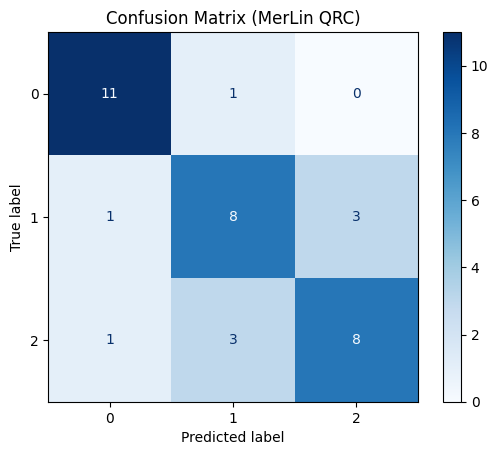

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    test_preds = model(X_test).argmax(dim=1)

cm = confusion_matrix(y_test.numpy(), test_preds.numpy())

print("\nConfusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (MerLin QRC)")
plt.show()

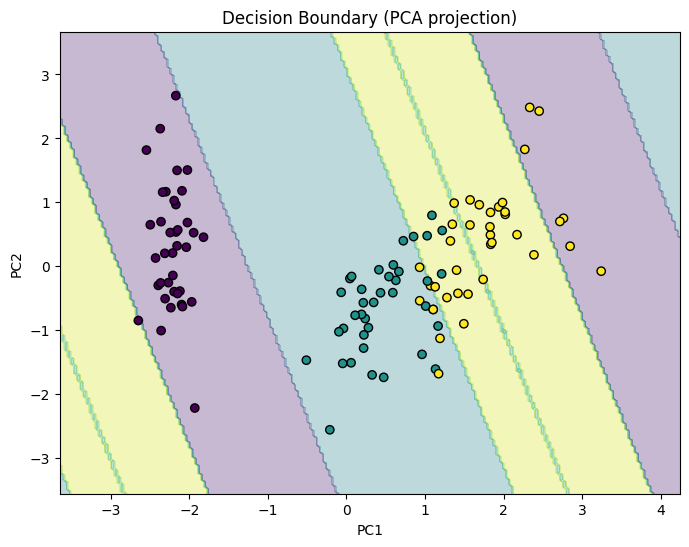

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Convert tensors to numpy
X_train_np = X_train.numpy()
y_train_np = y_train.numpy()

# PCA projection to 2D
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_np)

# Create mesh grid in PCA space
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Inverse transform back to 4D space
grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid_4d = pca.inverse_transform(grid_2d)
grid_4d = torch.tensor(grid_4d, dtype=torch.float32)

# Predict over grid
model.eval()
with torch.no_grad():
    Z = model(grid_4d).argmax(dim=1).numpy()

Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
            c=y_train_np, edgecolor='k')
plt.title("Decision Boundary (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

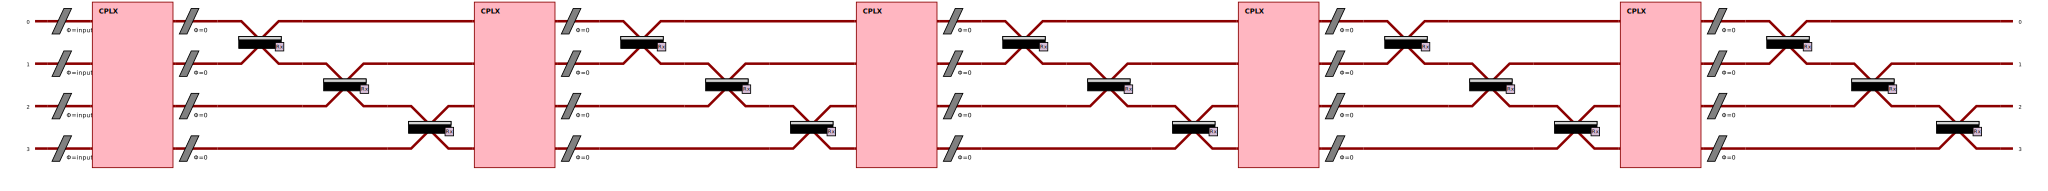

In [6]:
import perceval as pcvl
pcvl.pdisplay(quantum_reservoir.circuit)